<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_10_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Notebook: Reinforcement Learning

**You do not need to submit this Notebook.** It is for practice only.

## Introduction

This notebook explores the basics of Reinforcement Learning using the Gymnasium environment library.

### Goal

Keep a pole balanced on a moving cart.

### Documentation

https://gymnasium.farama.org/environments/classic_control/cart_pole/

## Import Libraries

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.animation
import matplotlib.pyplot as plt

import gymnasium as gym

Use JavaScript for the animation.

In [2]:
plt.rc("animation", html="jshtml")

## Helper Functions

This code was lightly modified from the book, *Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow* (3rd edition).

In [3]:
def display(env, figsize=(5, 4)):
    """
    Display the current time step of the environment.
    """
    fig = plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return fig

In [4]:
class Animator:

    @staticmethod
    def show_one_episode(policy):
        frames = []
        env = gym.make("CartPole-v1", render_mode="rgb_array")
        obs, _ = env.reset()
        steps = 0
        while True:
            frames.append(env.render())
            action = policy(obs)
            obs, _, done, truncated, _ = env.step(action)
            if done or truncated:
                break
            steps += 1
        env.close()
        print("Steps Performed:", steps)
        return Animator._plot_animation(frames)

    @staticmethod
    def _plot_animation(frames, interval=40):
        fig = plt.figure()
        patch = plt.imshow(frames[0])
        plt.axis("off")
        anim = matplotlib.animation.FuncAnimation(
            fig, Animator._update_scene, fargs=(frames, patch),
            frames=len(frames), repeat=False, interval=interval
        )
        plt.close()
        return anim

    @staticmethod
    def _update_scene(num, frames, patch):
        patch.set_data(frames[num])
        return (patch,)

## Creating an Environment

Environments start in a slightly randomized state.

In [5]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
obs

array([-0.02682488,  0.01598137,  0.04081719, -0.04518829], dtype=float32)

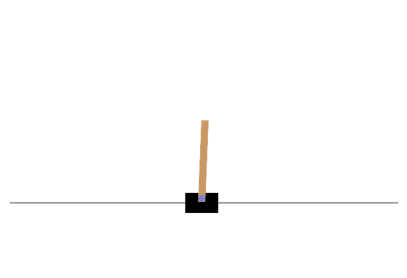

In [6]:
display(env)
plt.show()

### Available Actions

For this environment, there are only two actions: `0` to go left, and `1` to go right.

In [7]:
env.action_space

Discrete(2)

### Observations

After performing each action, the environment provides an observation vector. In this case, the values provided (in order) are:

- The cart's position
- The cart's velocity
- The pole's angle
- The pole's angular velocity

In [8]:
action = 1
obs, _, done, truncated, _ = env.step(action)

After this action, the cart is now moving toward the right.

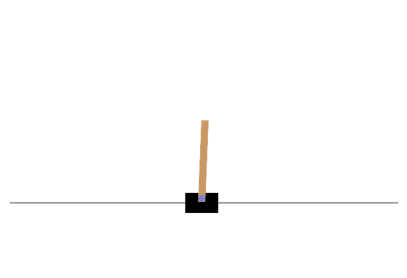

In [9]:
display(env)
plt.show()

### Terminating Condition

The simulation has finished when `done` or `truncated` is true.

For this environment, the terminating condition happens when the cart's position or the pole's angle exceed a threshold (see the documentation linked at the top for the exact values).

In [10]:
if done or truncated:
    obs, info = env.reset()

## A Simple Hard-Coded Policy

This basic policy only looks at whether the pole's angle is less than zero to determine the next action.

In [11]:
def basic_policy(obs):
    pole_ang = obs[2]
    return 0 if pole_ang < 0 else 1

### Animate the Result

In [12]:
Animator.show_one_episode(basic_policy)

Steps Performed: 44


## Q-Learning

### State Class

The class below is used to represent a state in the Cart-Pole environment.

Below, you can control which of the 4 values in the observation vector you would like to represent a state. More values gives more precision, at the cost of a larger Q-table that needs more time to train.

In [13]:
class CartPoleState:

    def __init__(self, obs):
        self.cart_pos = obs[0]
        self.cart_vel = obs[1]
        self.pole_ang = obs[2]
        self.pole_vel = obs[3]

    def __repr__(self) -> str:
        return ",".join((
            f"{self.cart_pos:+.1f}",
            f"{self.cart_vel:+.1f}",
            f"{self.pole_ang:+.2f}",
            f"{self.pole_vel:+.1f}"
        ))

    def __hash__(self) -> int:
        return hash(str(self))

### Initialize the Q-table

In [14]:
default = (0.0, 0.0)
qtable = {}

### Set Hyperparameters

In [15]:
n_iter = 100000
epsilon = 1.0
alpha = 0.5
gamma = 0.95

### Define a Reward Function

The reward function should incentivize the agent to keep the cart and pole centered with low velocity.

In [16]:
def reward(obs, base=1) -> float:
    cart_pos, cart_vel, pole_ang, pole_vel = obs
    return base - abs(cart_pos) - abs(cart_vel) - abs(pole_ang) - abs(pole_vel)

### Define the Policy

Given a state (observation), the policy needs to return an action - zero or one - based on the highest Q-value for that state in the Q-table.

In [17]:
def policy(obs) -> int:
    state = CartPoleState(obs)
    if qtable.get(str(state), default)[0] > qtable.get(str(state), default)[1]:
        return 0
    else:
        return 1

### Run the Learning Algorithm

In [18]:
for i in range(n_iter):
    obs, _ = env.reset()
    state = CartPoleState(obs)
    done = truncated = False
    while not done and not truncated:
        if random.random() < epsilon:
            action = random.choice((0, 1))
        else:
            action = policy(obs)
        qvalue = qtable.get(str(state), default)[action]

        obs, _, done, truncated, _ = env.step(action)
        state = CartPoleState(obs)

        best_next = max(qtable.get(str(state), default))
        qtable.setdefault(str(state), [0.0, 0.0])[action] = (
            (1 - alpha) * qvalue + alpha * (reward(obs) + gamma * best_next)
        )
    alpha = max(0.05, alpha - 1 / n_iter)
    epsilon = max(0.05, epsilon - 1 / n_iter)

In [19]:
pd.DataFrame(qtable).T.sort_index()

,0,1
"+0.0,+0.0,+0.00,+0.0",0.981077,0.610063
"+0.0,+0.0,+0.00,+0.1",0.134522,0.708092
"+0.0,+0.0,+0.00,+0.2",0.659109,0.000000
"+0.0,+0.0,+0.00,-0.0",0.978925,0.613060
"+0.0,+0.0,+0.00,-0.1",0.000000,0.100678
...,...,...
"-2.3,-2.0,+0.06,+1.0",0.000000,-1.238056
"-2.3,-2.2,+0.03,+1.3",-2.213532,0.000000
"-2.3,-2.2,+0.08,+1.3",-1.397132,0.000000
"-2.4,-1.8,+0.13,+0.8",0.000000,-2.105615


### Animate the Result

In [20]:
Animator.show_one_episode(policy)

Steps Performed: 8


## Keep Practicing!

Try out different state representations and other hyperparameters to see if you can keep the pole balanced for more time steps.